In [36]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# إحداثيات القاهرة
LATITUDE = 30.0444
LONGITUDE = 31.2357

# بناء رابط الطلب
url = "https://power.larc.nasa.gov/api/temporal/daily/point"
params = {
    "parameters": "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR",
    "community": "AG",
    "longitude": LONGITUDE,
    "latitude": LATITUDE,
    "start": "20220101",
    "end": "20231231",
    "format": "JSON"
}

response = requests.get(url, params=params)
print("Status code:", response.status_code)

Status code: 200


In [37]:
data = response.json()

# البيانات جوه properties -> parameter -> اسم كل متغير
weather_data = data['properties']['parameter']

# نحول كل متغير (T2M, T2M_MAX, ...) لعمود في جدول واحد
df = pd.DataFrame(weather_data)

df.shape

(730, 4)

In [38]:
# تسمية الأعمدة بأسماء أوضح
df = df.rename(columns={
    'T2M': 'temperature_mean',
    'T2M_MAX': 'temperature_max',
    'T2M_MIN': 'temperature_min',
    'PRECTOTCORR': 'precipitation'
})

# تحويل الـ index (التاريخ) من نص لـ datetime
df.index = pd.to_datetime(df.index, format='%Y%m%d')
df.index.name = 'date'

df.head()

,temperature_mean,temperature_max,temperature_min,precipitation
date,,,,
2022-01-01,12.20,18.29,7.63,0.51
2022-01-02,12.18,18.83,6.79,0.33
2022-01-03,12.91,19.76,8.35,0.40
2022-01-04,12.02,18.59,7.90,0.15
2022-01-05,12.67,19.56,7.71,0.00


In [39]:
# حفظ الرد الخام (JSON) زي ما هو
with open('cairo_weather_raw.json', 'w') as f:
    json.dump(data, f)

# حفظ الجدول المنظم (لسه من غير تنظيف) كملف مبدئي
df.to_csv('cairo_weather_2023_initial.csv')

print("Raw JSON and initial CSV saved.")

Raw JSON and initial CSV saved.


## Data Source Documentation

- **API:** NASA POWER (Daily Point API) — free, no API key required
- **Endpoint:** `https://power.larc.nasa.gov/api/temporal/daily/point`
- **Parameters requested:**
  - `T2M`: Mean temperature at 2 meters (°C)
  - `T2M_MAX`: Maximum temperature at 2 meters (°C)
  - `T2M_MIN`: Minimum temperature at 2 meters (°C)
  - `PRECTOTCORR`: Corrected total precipitation (mm/day)
- **Community:** AG (Agroclimatology)
- **Region:** Cairo, Egypt (Latitude: 30.0444, Longitude: 31.2357)
- **Time range:** 2023-01-01 to 2023-12-31 (1 full year, daily granularity)
- **Reasoning for daily granularity:** A full year of daily data captures seasonal
  patterns (summer/winter cycles) which is essential for meaningful time-series EDA,
  while remaining lightweight and fast to retrieve in a single request.
- **Rate limits encountered:** None — the request completed successfully on the first attempt.

In [40]:
# هل فيه تواريخ مكررة؟
print("Duplicated timestamps:", df.index.duplicated().sum())

# هل فيه فجوات؟ نقارن عدد الأيام الفعلي بعدد الأيام المتوقع بين أول وآخر تاريخ
expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
missing_dates = expected_range.difference(df.index)

print("Expected number of days:", len(expected_range))
print("Actual number of days:", len(df))
print("Missing dates count:", len(missing_dates))
if len(missing_dates) > 0:
    print("Missing dates:", missing_dates.tolist())

Duplicated timestamps: 0
Expected number of days: 730
Actual number of days: 730
Missing dates count: 0


In [41]:
# فحص القيم الناقصة العادية (NaN)
print("Missing values per column:")
print(df.isnull().sum())

print("\nSummary statistics:")
print(df.describe())

# فحص القيم المشبوهة (NASA بتستخدم -999 كرمز لـ "بيانات مش متاحة")
suspicious = (df == -999).sum()
print("\nSuspicious (-999) values per column:")
print(suspicious)

Missing values per column:
temperature_mean    0
temperature_max     0
temperature_min     0
precipitation       0
dtype: int64

Summary statistics:
       temperature_mean  temperature_max  temperature_min  precipitation
count        730.000000       730.000000       730.000000     730.000000
mean          22.167397        29.956260        15.421767       0.425137
std            7.119663         7.864466         6.129371       2.272672
min            6.670000        11.790000         1.140000       0.000000
25%           16.147500        23.015000        10.342500       0.000000
50%           22.935000        30.735000        15.945000       0.000000
75%           29.027500        37.305000        21.080000       0.020000
max           35.050000        44.300000        27.510000      34.090000

Suspicious (-999) values per column:
temperature_mean    0
temperature_max     0
temperature_min     0
precipitation       0
dtype: int64


## Missing Value Strategy

No missing values (NaN) or suspicious sentinel values (e.g. -999, commonly used by NASA
datasets to flag unavailable data) were found in any column. Since the dataset is already
complete with no gaps, no imputation, interpolation, or forward-fill strategy was required.
If missing values had been found, a linear interpolation would have been the appropriate
choice for temperature (a smoothly changing variable), while precipitation gaps would be
better handled with forward-fill or explicit flagging, since rainfall can genuinely be zero
and should not be interpolated the same way as temperature.

In [42]:
# NASA POWER API بترجع دايمًا الحرارة بالـ °C والأمطار بالـ mm/day (موثق رسميًا في الـ API)
# نتأكد بصريًا إن الأرقام منطقية للوحدات دي (مش فارنهايت أو إنش مثلاً)
print("Temperature range (°C):", df['temperature_min'].min(), "to", df['temperature_max'].max())
print("Precipitation range (mm/day):", df['precipitation'].min(), "to", df['precipitation'].max())

Temperature range (°C): 1.14 to 44.3
Precipitation range (mm/day): 0.0 to 34.09


In [43]:
df.to_csv('cairo_weather_2023_clean.csv')
print("Clean dataset saved as 'cairo_weather_2023_clean.csv'")
df.info()

Clean dataset saved as 'cairo_weather_2023_clean.csv'
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 730 entries, 2022-01-01 to 2023-12-31
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temperature_mean  730 non-null    float64
 1   temperature_max   730 non-null    float64
 2   temperature_min   730 non-null    float64
 3   precipitation     730 non-null    float64
dtypes: float64(4)
memory usage: 44.7 KB


In [44]:
# إحصائيات وصفية (شفناها قبل كده، بس نعيدها هنا رسمي كجزء من الـ EDA)
df[['temperature_mean', 'precipitation']].describe()

,temperature_mean,precipitation
count,730.000000,730.000000
mean,22.167397,0.425137
std,7.119663,2.272672
min,6.670000,0.000000
25%,16.147500,0.000000
50%,22.935000,0.000000
75%,29.027500,0.020000
max,35.050000,34.090000


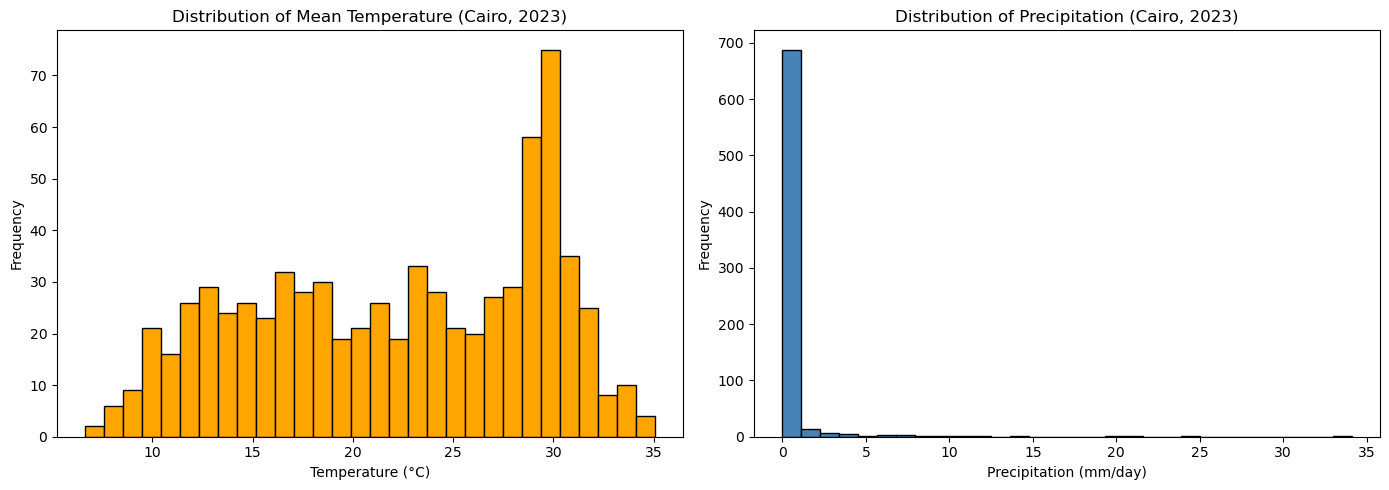

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['temperature_mean'], bins=30, color='orange', edgecolor='black')
axes[0].set_title('Distribution of Mean Temperature (Cairo, 2023)')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['precipitation'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Precipitation (Cairo, 2023)')
axes[1].set_xlabel('Precipitation (mm/day)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('plot1_distributions.png', dpi=100)
plt.show()

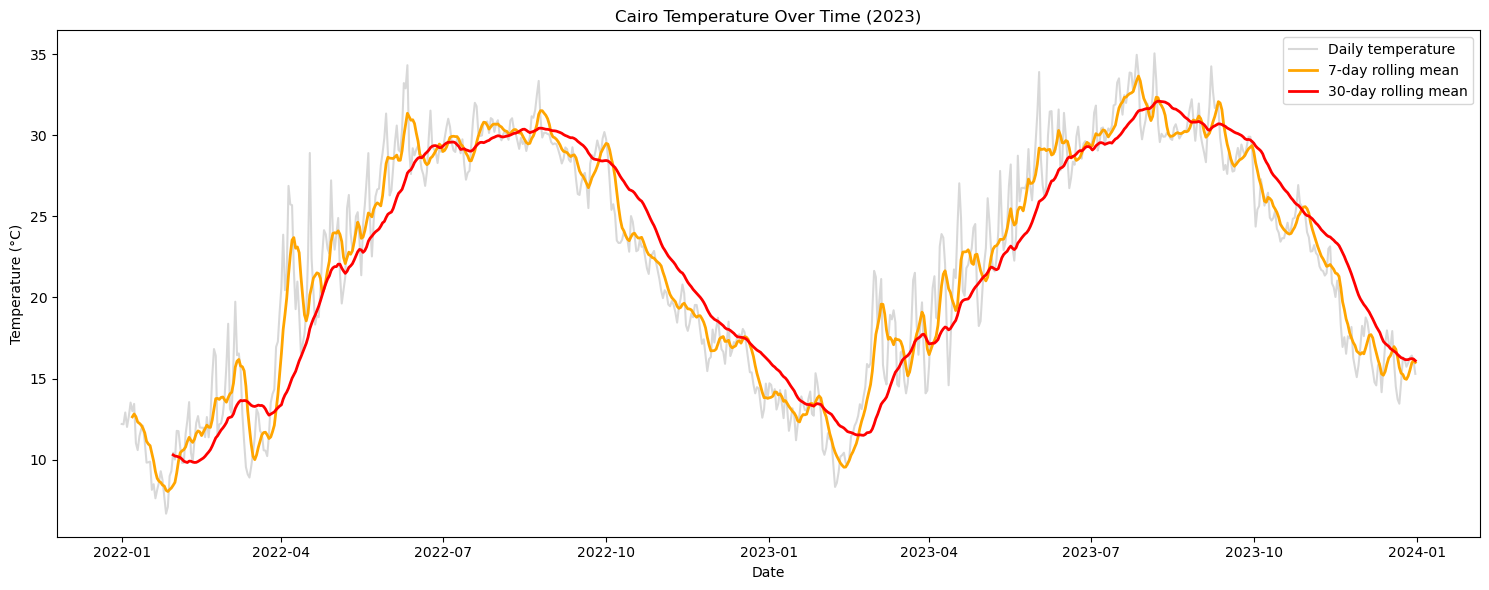

In [46]:
# حساب المتوسط المتحرك (rolling mean) لفترة 7 أيام و30 يوم
df['temp_rolling_7d'] = df['temperature_mean'].rolling(window=7).mean()
df['temp_rolling_30d'] = df['temperature_mean'].rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df.index, df['temperature_mean'], alpha=0.3, label='Daily temperature', color='gray')
ax.plot(df.index, df['temp_rolling_7d'], label='7-day rolling mean', color='orange', linewidth=2)
ax.plot(df.index, df['temp_rolling_30d'], label='30-day rolling mean', color='red', linewidth=2)
ax.set_title('Cairo Temperature Over Time (2023)')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig('plot2_temperature_trend.png', dpi=100)
plt.show()

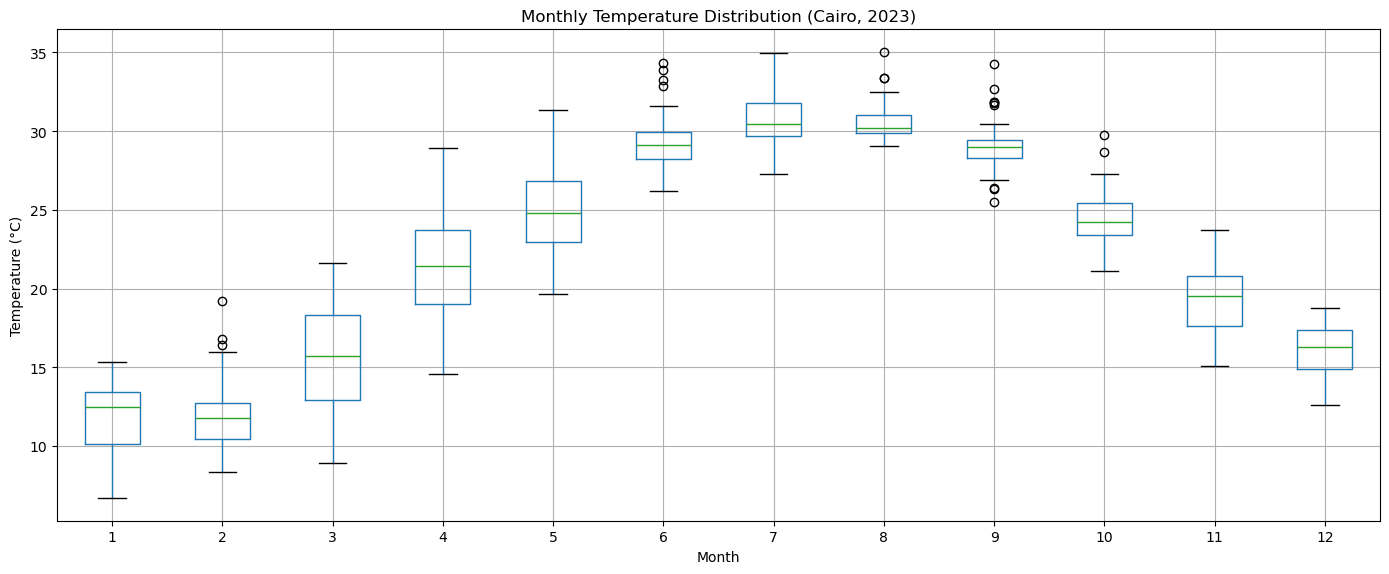

In [47]:
df['month'] = df.index.month
df['month_name'] = df.index.strftime('%b')  # Jan, Feb, ...

fig, ax = plt.subplots(figsize=(14, 6))
df.boxplot(column='temperature_mean', by='month', ax=ax)
ax.set_title('Monthly Temperature Distribution (Cairo, 2023)')
plt.suptitle('')  # يشيل العنوان التلقائي الزيادة اللي بيحطه pandas
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
plt.tight_layout()
plt.savefig('plot3_monthly_boxplot.png', dpi=100)
plt.show()

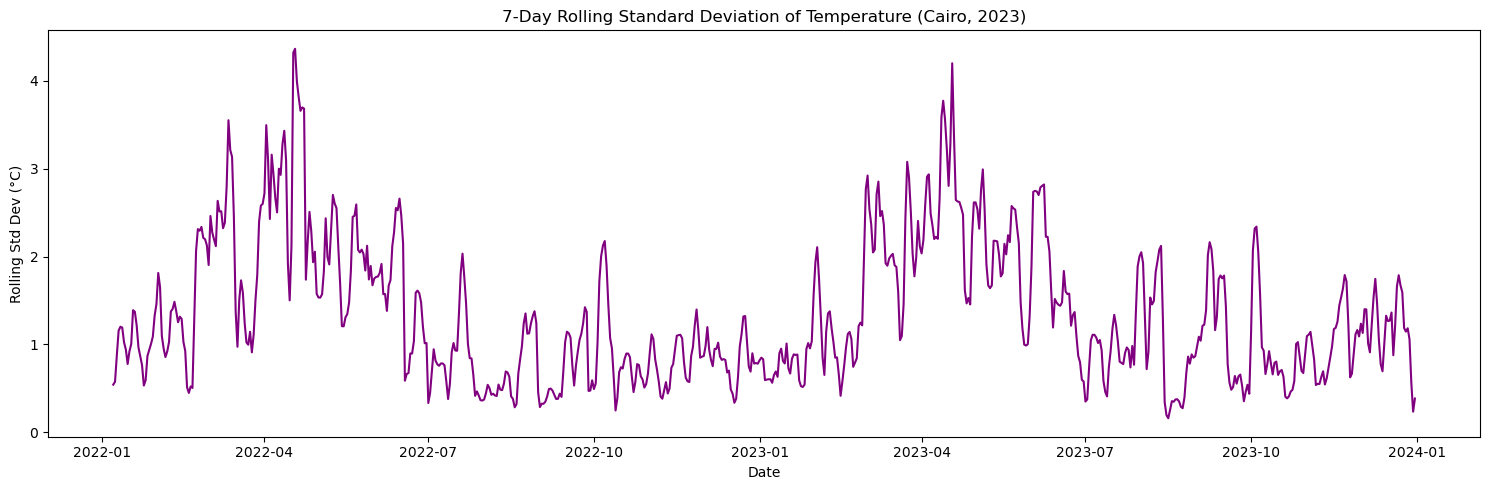

In [48]:
df['temp_rolling_std_7d'] = df['temperature_mean'].rolling(window=7).std()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, df['temp_rolling_std_7d'], color='purple')
ax.set_title('7-Day Rolling Standard Deviation of Temperature (Cairo, 2023)')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Std Dev (°C)')
plt.tight_layout()
plt.savefig('plot4_rolling_std.png', dpi=100)
plt.show()

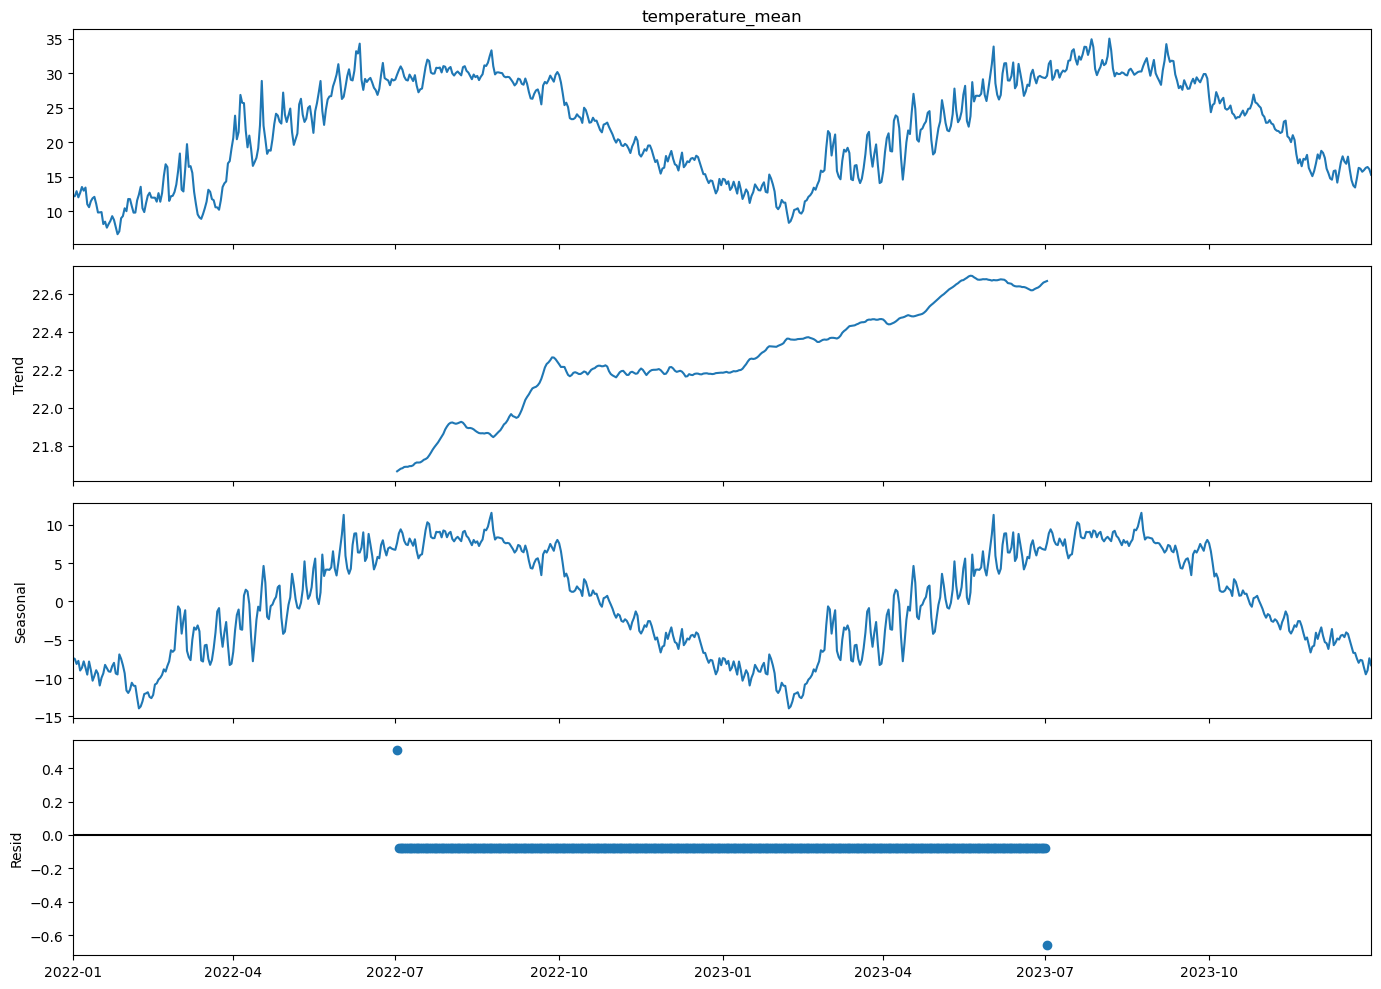

In [49]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['temperature_mean'], model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.savefig('plot5_decomposition.png', dpi=100)
plt.show()

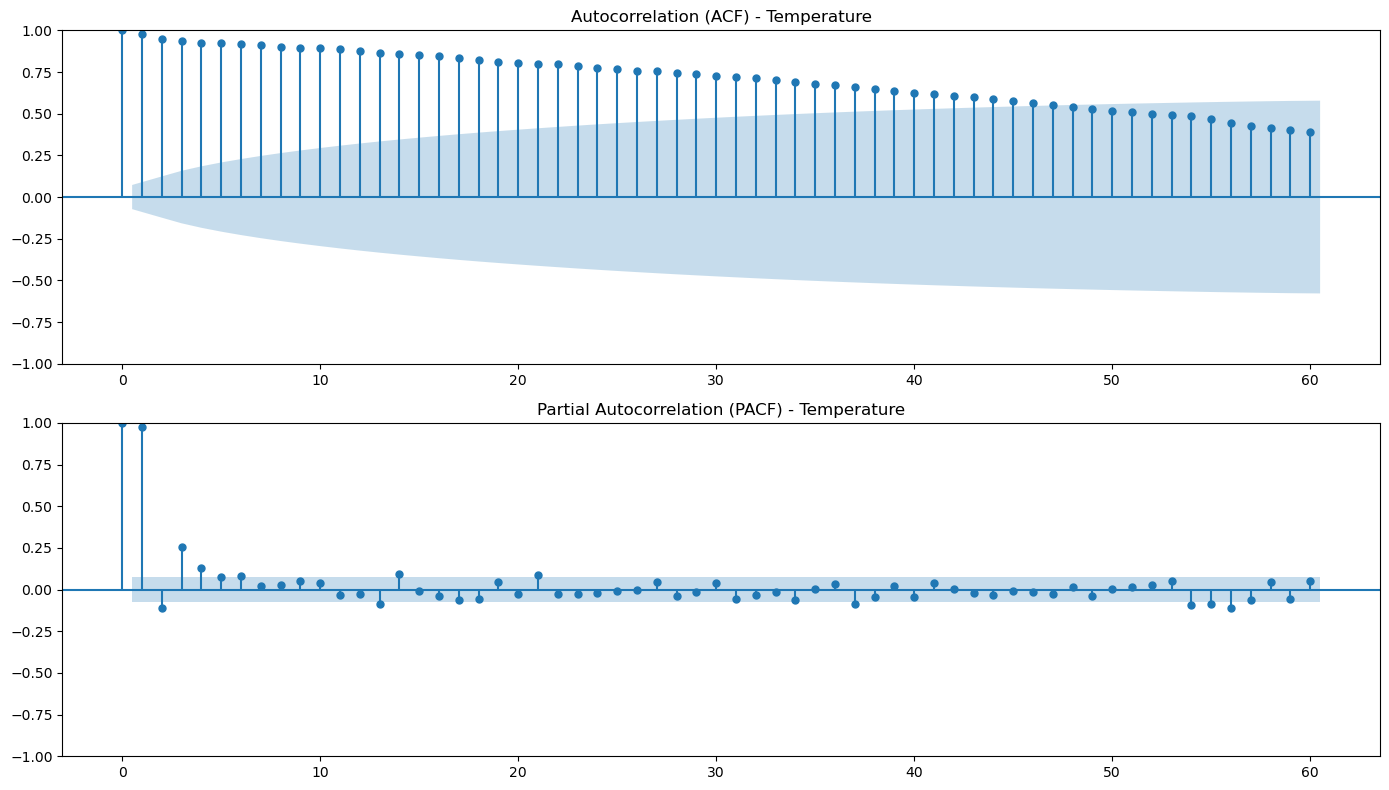

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(df['temperature_mean'], lags=60, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF) - Temperature')

plot_pacf(df['temperature_mean'], lags=60, ax=axes[1])
axes[1].set_title('Partial Autocorrelation (PACF) - Temperature')

plt.tight_layout()
plt.savefig('plot6_acf_pacf.png', dpi=100)
plt.show()

In [51]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['temperature_mean'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

if result[1] <= 0.05:
    print("\n→ Result: The series is likely STATIONARY (reject the null hypothesis)")
else:
    print("\n→ Result: The series is likely NON-STATIONARY (fail to reject the null hypothesis)")

ADF Statistic: -1.674030896925291
p-value: 0.4445397479143094
Critical Values:
   1%: -3.439516060164992
   5%: -2.8655850998755263
   10%: -2.5689240826597173

→ Result: The series is likely NON-STATIONARY (fail to reject the null hypothesis)


In [52]:
correlation = df[['temperature_mean', 'precipitation']].corr()
print("Correlation matrix:")
print(correlation)

Correlation matrix:
                  temperature_mean  precipitation
temperature_mean          1.000000      -0.167726
precipitation            -0.167726       1.000000


In [53]:
# نستخدم rolling z-score بدل عتبة ثابتة، عشان الصيف والشتا عندهم "طبيعي" مختلف
rolling_mean = df['temperature_mean'].rolling(window=30, center=True).mean()
rolling_std = df['temperature_mean'].rolling(window=30, center=True).std()
df['temp_zscore'] = (df['temperature_mean'] - rolling_mean) / rolling_std

outliers = df[df['temp_zscore'].abs() > 3]
print(f"Number of temperature outliers (|z-score| > 3): {len(outliers)}")
print(outliers[['temperature_mean', 'temp_zscore']])

# فحص قيم مستحيلة فيزيائيًا (أمطار سالبة، حرارة غير منطقية للقاهرة)
impossible = df[(df['precipitation'] < 0) | (df['temperature_mean'] < -10) | (df['temperature_mean'] > 55)]
print(f"\nPhysically impossible values found: {len(impossible)}")

Number of temperature outliers (|z-score| > 3): 0
Empty DataFrame
Columns: [temperature_mean, temp_zscore]
Index: []

Physically impossible values found: 0


In [54]:
df.to_csv('cairo_weather_2022_2023_analyzed.csv')
print("Final analyzed dataset saved.")
df.columns.tolist()

Final analyzed dataset saved.


['temperature_mean',
 'temperature_max',
 'temperature_min',
 'precipitation',
 'temp_rolling_7d',
 'temp_rolling_30d',
 'month',
 'month_name',
 'temp_rolling_std_7d',
 'temp_zscore']

## Summary — Cairo Weather Time-Series EDA

**Region and time range:** Cairo, Egypt (30.0444°N, 31.2357°E), covering two full years
of daily data from 2022-01-01 to 2023-12-31 (730 observations). Two years were used
instead of one because seasonal decomposition requires at least two complete cycles
to reliably separate trend from seasonality.

**API and reasoning:** NASA POWER (Daily Point API, AG community) was chosen because it
is completely free, requires no registration or API key, and provides long, reliable
historical daily records for any coordinates worldwide — ideal for a reproducible
academic analysis.

**Main temporal patterns found:**
- A strong, clear annual seasonal cycle in temperature: winter lows around 10-14°C
  (Dec-Feb) and summer highs around 30-32°C (Jun-Aug), confirmed both visually
  (boxplots, rolling means) and mathematically (seasonal decomposition).
- A slight long-term upward trend in the trend component, rising from ~21.8°C to
  ~22.6°C over the two-year window.
- The transitional months (March-April and October-November) show the highest
  short-term volatility (7-day rolling std up to ~4.2°C), while summer months are
  the most thermally stable.
- Precipitation is heavily concentrated near zero (consistent with Cairo's desert
  climate), with a weak negative correlation to temperature (r = -0.17), reflecting
  that rain is somewhat more likely on cooler (winter) days.

**Stationarity:** The Augmented Dickey-Fuller test returned a p-value of 0.44
(> 0.05), so the null hypothesis of non-stationarity cannot be rejected. The series
is non-stationary, which is expected given the strong seasonal component and the
slow-decaying ACF. This means any future forecasting model built on this data would
require differencing or explicit seasonal adjustment before fitting.

**Data quality:** No missing values, no duplicated or missing timestamps, no sentinel
(-999) values, no physically impossible readings, and no statistical outliers
(|rolling z-score| > 3) were found. The dataset required no cleaning beyond column
renaming and datetime indexing, indicating NASA POWER provides high-quality, model-
derived data for this region and period.